In [1]:
# WP3: Standardisation and Normalisation
# Approach: automated synonym detection (FastText) + manual validation
#           spelling/casing/formatting normalisation
#           reproducible preprocessing pipeline

In [3]:
# install missing dependency
!pip install gensim --quiet

# WP3: Standardisation and Normalisation

The goal of this notebook is to normalise the CT-RATE radiology reports 
to reduce lexical variation that could affect downstream LLM querying.

We follow a three-step approach:
1. **Terminology analysis**: identify the most frequent terms and their 
   variants in the dataset
2. **Lexical mapping**: use FastText to find synonym candidates, then 
   manually validate and define mappings based on the 18 CT-RATE 
   abnormality categories
3. **Normalisation pipeline**: apply spelling, casing, formatting and 
   lexical normalisation to `Findings_EN` and `Impressions_EN`

In [4]:
# ============================================================
# CELL 1 - Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import json
from collections import Counter
from gensim.models import FastText
from gensim.utils import simple_preprocess

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Imports done.")

Imports done.


## 1. Loading the Data

We load the combined CT-RATE dataset from WP1 and apply the same 
deduplication as in WP2 - one report per unique scan.

In [8]:
# ============================================================
# CELL 2 - Load data
# ============================================================

# we build on the deduplicated dataset from WP2
# this already has one row per unique scan (~24k reports)
# and includes the style_id assignments from WP2
df = pd.read_csv('../WP2/df_wp2_final.csv')

texts_findings    = df['Findings_EN'].fillna('').tolist()
texts_impressions = df['Impressions_EN'].fillna('').tolist()
texts_all         = [f + ' ' + i
                     for f, i in zip(texts_findings, texts_impressions)]

print(f"Loaded {len(df)} deduplicated reports (WP2 output).")
print(f"Columns: {df.shape[1]}")
print(f"\nExample finding (first 200 chars):")
print(texts_findings[0][:200])

Loaded 24113 deduplicated reports (WP2 output).
Columns: 75

Example finding (first 200 chars):
Multiple venous collaterals are present in the anterior left chest wall and are associated with the anterior jugular vein at the level of the right sternoclavicular junction. Left subclavian vein coll


## 2. Terminology Analysis

Before normalising, we want to understand what terms are actually used 
in the dataset and how frequently. We focus on the 18 abnormality 
categories from the CT-RATE paper.

In [9]:
# ============================================================
# CELL 3 - Term frequency analysis
# ============================================================

# the 18 CT-RATE abnormality categories with known synonyms/variants
ABNORMALITY_TERMS = {
    'medical_material':    ['medical material', 'implant', 'device', 'pacemaker', 'stent', 'catheter', 'port'],
    'calcification':       ['calcification', 'calcified', 'calcific', 'calcium', 'atheroma', 'atherosclerosis'],
    'cardiomegaly':        ['cardiomegaly', 'enlarged heart', 'cardiac enlargement', 'increased heart size'],
    'pericardial_effusion':['pericardial effusion', 'pericardial fluid', 'pericardial thickening'],
    'hiatal_hernia':       ['hiatal hernia', 'hiatus hernia', 'hernia'],
    'lymphadenopathy':     ['lymphadenopathy', 'enlarged lymph node', 'lymph node enlargement', 'lap'],
    'emphysema':           ['emphysema', 'emphysematous', 'bullae', 'bulla'],
    'atelectasis':         ['atelectasis', 'atelectatic', 'collapse', 'subsegmental atelectasis'],
    'lung_nodule':         ['nodule', 'nodular', 'mass', 'pulmonary nodule'],
    'lung_opacity':        ['opacity', 'opacities', 'ground glass', 'ground-glass', 'infiltrate',
                            'infiltration', 'density', 'densities'],
    'pulmonary_fibrosis':  ['fibrosis', 'fibrotic', 'sequela', 'sequelae', 'scarring'],
    'pleural_effusion':    ['pleural effusion', 'pleural fluid', 'hydrothorax'],
    'mosaic_attenuation':  ['mosaic', 'mosaic attenuation', 'mosaic pattern'],
    'peribronchial_thickening': ['peribronchial thickening', 'peribronchial', 'bronchial wall thickening'],
    'consolidation':       ['consolidation', 'consolidated', 'consolidative'],
    'bronchiectasis':      ['bronchiectasis', 'bronchiectatic', 'bronchial dilation'],
    'interlobular_septal_thickening': ['interlobular septal thickening', 'septal thickening', 'kerley lines'],
    'other':               ['pleural thickening', 'pneumothorax', 'pneumonia'],
}

# count occurrences of each term in the dataset
print("=== Term Frequency Analysis ===\n")
term_counts = {}

for category, terms in ABNORMALITY_TERMS.items():
    print(f"{category}:")
    category_counts = {}
    for term in terms:
        count = sum(1 for t in texts_all if term.lower() in t.lower())
        category_counts[term] = count
        print(f"  {term:40s}: {count:6d} ({count/len(df)*100:.1f}%)")
    term_counts[category] = category_counts
    print()

=== Term Frequency Analysis ===

medical_material:
  medical material                        :      4 (0.0%)
  implant                                 :     94 (0.4%)
  device                                  :     12 (0.0%)
  pacemaker                               :    243 (1.0%)
  stent                                   :   4800 (19.9%)
  catheter                                :   1240 (5.1%)
  port                                    :    931 (3.9%)

calcification:
  calcification                           :   2167 (9.0%)
  calcified                               :   2970 (12.3%)
  calcific                                :   6490 (26.9%)
  calcium                                 :      3 (0.0%)
  atheroma                                :   5227 (21.7%)
  atherosclerosis                         :    864 (3.6%)

cardiomegaly:
  cardiomegaly                            :   1378 (5.7%)
  enlarged heart                          :      1 (0.0%)
  cardiac enlargement                     : 

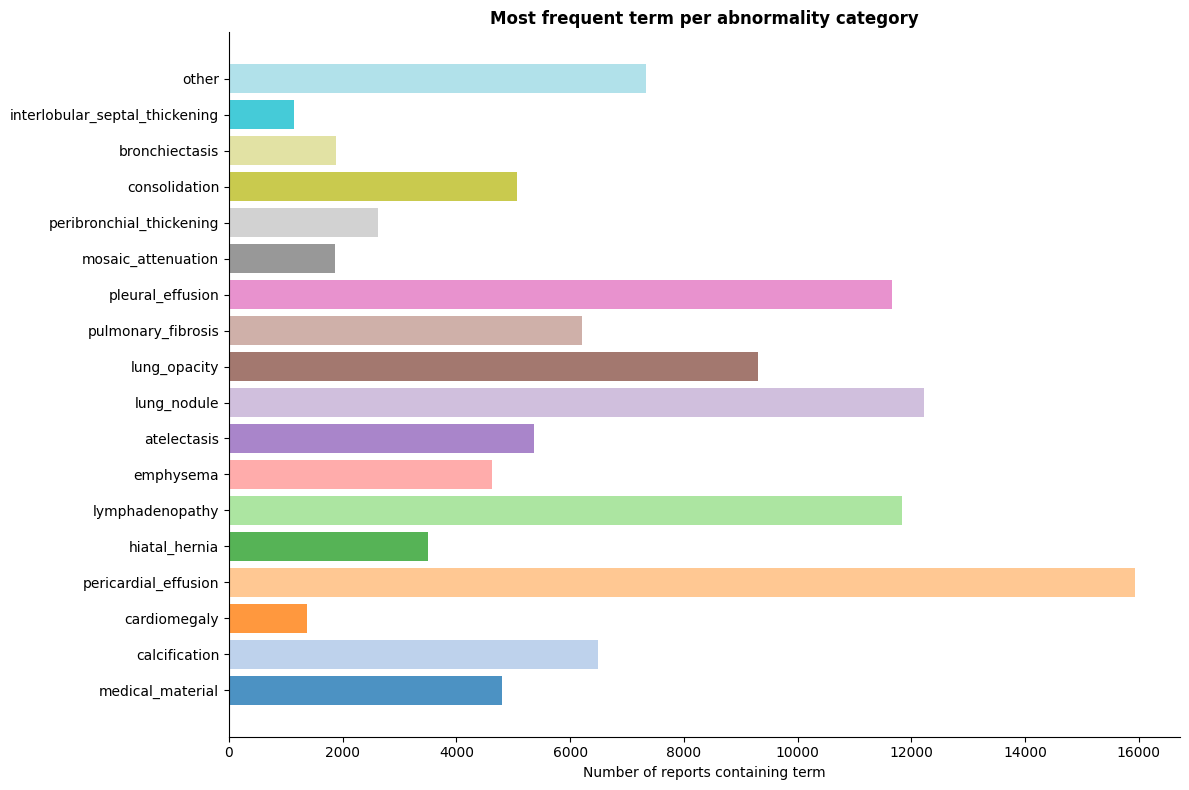

Saved: figures/term_frequency.png


In [10]:
# ============================================================
# CELL 4 - Visualize term frequency per category
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

categories  = list(ABNORMALITY_TERMS.keys())
# take the most frequent term per category as representative
max_counts  = [max(term_counts[cat].values()) for cat in categories]

colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))
bars   = ax.barh(categories, max_counts, color=colors, alpha=0.8)

ax.set_title('Most frequent term per abnormality category',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Number of reports containing term')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'term_frequency.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/term_frequency.png")

## 3. FastText Synonym Detection

We train a FastText model on the CT-RATE reports to find terms that are 
used in similar contexts. FastText is particularly well-suited for medical 
text because it handles rare terms and morphological variants 
(e.g. "fibrotic" vs "fibrosis") by breaking words into character n-grams.

The model is trained on the combined findings and impressions text.
After training, we query it for synonym candidates for each of our 
key abnormality terms.

In [11]:
# ============================================================
# CELL 5 - Train FastText model
# ============================================================

# tokenize all texts
print("Tokenizing texts...")
tokenized = [simple_preprocess(text) for text in texts_all]

print(f"Training FastText on {len(tokenized)} documents...")
ft_model = FastText(
    sentences=tokenized,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=5,       # ignore terms appearing less than 5 times
    epochs=10,
    workers=4,
    sg=1               # skip-gram (better for rare words)
)

print(f"FastText trained!")
print(f"  Vocabulary size: {len(ft_model.wv)}")
print(f"  Embedding dim:   {ft_model.vector_size}")

# save model for reuse
ft_model.save('fasttext_wp3.model')
print(f"  Model saved: fasttext_wp3.model")

Tokenizing texts...
Training FastText on 24113 documents...
FastText trained!
  Vocabulary size: 3103
  Embedding dim:   100
  Model saved: fasttext_wp3.model


In [12]:
# ============================================================
# CELL 6 - Find synonym candidates
# ============================================================

# key terms to find synonyms for
QUERY_TERMS = [
    'opacity', 'consolidation', 'infiltrate', 'fibrosis',
    'atelectasis', 'nodule', 'effusion', 'emphysema',
    'calcification', 'thickening', 'sequela', 'bronchiectasis'
]

print("=== FastText Synonym Candidates ===\n")
synonym_candidates = {}

for term in QUERY_TERMS:
    try:
        similar = ft_model.wv.most_similar(term, topn=10)
        synonym_candidates[term] = similar
        print(f"{term}:")
        for word, score in similar:
            print(f"  {word:30s}: {score:.3f}")
        print()
    except KeyError:
        print(f"{term}: not in vocabulary\n")

=== FastText Synonym Candidates ===

opacity:
  opacities                     : 0.764
  condolidation                 : 0.645
  halos                         : 0.628
  barely                        : 0.620
  consolidation                 : 0.588
  infiltrates                   : 0.588
  subplebral                    : 0.579
  condolidations                : 0.572
  subpleura                     : 0.572
  patches                       : 0.569

consolidation:
  condolidation                 : 0.871
  consolidating                 : 0.797
  condolidations                : 0.795
  consolidate                   : 0.787
  consolidations                : 0.767
  consolidated                  : 0.761
  consolidative                 : 0.706
  bronchograms                  : 0.670
  airbronchograms               : 0.655
  bronchogram                   : 0.609

infiltrate:
  infiltrated                   : 0.951
  infiltrates                   : 0.855
  infiltrations                 : 0.829
  inf

## 4. Manual Lexical Mappings

Based on the term frequency analysis and FastText synonym candidates, 
we now define the final lexical mappings. The goal is to map variant 
terms to a single canonical form for each concept.

These mappings are informed by:
- The 18 CT-RATE abnormality categories
- The FastText synonym candidates
- Domain knowledge from the CT-RATE paper

In [27]:
# ============================================================
# CELL 7 - Define lexical mappings
# ============================================================

# Decisions are based on:
# 1. CT-RATE paper: 18 abnormality categories define the canonical terms
# 2. Term frequency analysis (Cell 3): shows which variants actually occur
# 3. FastText synonym candidates (Cell 6): data-driven synonym suggestions
#
# Important: noun forms and adjective forms are mapped separately
# to avoid ungrammatical replacements (e.g. "calcific" -> "calcification")

LEXICAL_MAPPINGS = {

    # --- LUNG OPACITY ---
    'ground_glass_opacity': [
        'ground-glass opacity',
        'ground glass opacity',
        'ground-glass',
        'ground glass',
        'gg opacity',
        'ggo',
    ],
    'lung_opacity': [
        'infiltrate',
        'infiltration',
        'infiltrates',
        'infiltrations',
        'infiltrating',
        'infiltrated',
    ],

    # --- CONSOLIDATION (nouns) ---
    'consolidation': [
        'consolidations',
    ],
    # adjective forms mapped separately
    'consolidative': [
        'consolidating',
        'consolidated',
    ],

    # --- FIBROSIS (nouns) ---
    'fibrosis': [
        'sequela',
        'sequelae',
    ],
    # adjective forms mapped separately
    'fibrotic': [
        'fibrotic changes',
        'fibrotic sequelae',
    ],

    # --- ATELECTASIS (nouns) ---
    'atelectasis': [
        'subsegmental atelectasis',
        'linear atelectasis',
        'passive atelectasis',
        'compressive atelectasis',
        'discoid atelectasis',
        'atelectases',
    ],
    # adjective forms mapped separately
    'atelectatic': [
        'atelectatic changes',
    ],

    # --- EMPHYSEMA (nouns) ---
    'emphysema': [
        'panlobular emphysema',
        'paraseptal emphysema',
        'centrilobular emphysema',
        'bullous emphysema',
    ],
    # adjective forms mapped separately
    'emphysematous': [
        'emphysematous changes',
        'emphysematous bullae',
    ],

    # --- CALCIFICATION (nouns) ---
    # calcification: 9.0%, calcifications: rare
    'calcification': [
        'calcifications',
    ],
    # adjective forms mapped separately
    # calcific: 26.9%, calcified: 12.3%
    'calcific': [
        'calcified',
        'calcific changes',
    ],

    # --- EFFUSION ---
    'pleural_effusion': [
        'pleural fluid',
        'pleural collection',
    ],
    'pericardial_effusion': [
        'pericardial fluid',
    ],

    # --- LYMPHADENOPATHY ---
    # lap is an abbreviation (6.5%) - expand to full term
    'lymphadenopathy': [
        'lap',
        'lymph node enlargement',
        'pathological lymph nodes',
    ],

    # --- BRONCHIECTASIS (nouns) ---
    'bronchiectasis': [
        'cylindrical bronchiectasis',
        'tubular bronchiectasis',
        'saccular bronchiectasis',
    ],
    # adjective forms mapped separately
    'bronchiectatic': [],

    # --- SEPTAL THICKENING ---
    'septal_thickening': [
        'interlobular septal thickening',
        'septal thickening',
        'interlobular thickening',
    ],

    # --- MOSAIC ATTENUATION ---
    'mosaic_attenuation': [
        'mosaic pattern',
        'mosaic appearance',
    ],
}

print(f"Defined {len(LEXICAL_MAPPINGS)} lexical mapping groups:")
for canonical, variants in LEXICAL_MAPPINGS.items():
    n = len(variants)
    print(f"  {canonical:35s}: {n} variant{'s' if n != 1 else ''}")

# save as JSON
with open('lexical_mappings.json', 'w') as f:
    json.dump(LEXICAL_MAPPINGS, f, indent=2)
print(f"\nSaved: lexical_mappings.json")

Defined 19 lexical mapping groups:
  ground_glass_opacity               : 6 variants
  lung_opacity                       : 6 variants
  consolidation                      : 1 variant
  consolidative                      : 2 variants
  fibrosis                           : 2 variants
  fibrotic                           : 2 variants
  atelectasis                        : 6 variants
  atelectatic                        : 1 variant
  emphysema                          : 4 variants
  emphysematous                      : 2 variants
  calcification                      : 1 variant
  calcific                           : 2 variants
  pleural_effusion                   : 2 variants
  pericardial_effusion               : 1 variant
  lymphadenopathy                    : 3 variants
  bronchiectasis                     : 3 variants
  bronchiectatic                     : 0 variants
  septal_thickening                  : 3 variants
  mosaic_attenuation                 : 2 variants

Saved: lexical_map

## 5. Normalisation Pipeline

We now apply a full normalisation pipeline to `Findings_EN` and 
`Impressions_EN`. The pipeline consists of four steps applied in order:

1. **Casing**: convert to lowercase
2. **Spelling**: fix common typos and inconsistencies
3. **Formatting**: normalise whitespace, punctuation, hyphens
4. **Lexical**: apply the mappings defined above

In [28]:
# ============================================================
# CELL 8 - Define spelling corrections
# ============================================================

# Typos identified via FastText (Cell 6) and manual inspection
# FastText found these because they cluster near the correct term
# in the embedding space - strong evidence they are typos

SPELLING_CORRECTIONS = {
    # found by FastText - consolidation typos
    'condolidation':    'consolidation',
    'condolidations':   'consolidations',

    # found by FastText - atelectasis typos
    'atelectesis':      'atelectasis',
    'ateletasis':       'atelectasis',
    'atelectic':        'atelectatic',
    'fibroatelectic':   'fibroatelectatic',

    # found by FastText - emphysema typos
    'emphysemetous':    'emphysematous',
    'emphysemato':      'emphysematous',

    # found by FastText - pericardial typos
    'percardial':       'pericardial',
    'pericardiac':      'pericardial',

    # found by FastText - peribronchial typos
    'peribonchial':     'peribronchial',
    'peribrochial':     'peribronchial',
    'peribronchially':  'peribronchially',

    # found by FastText - opacity related
    'subplebral':       'subpleural',

    # found manually in sample reports
    'milimetric':       'millimetric',
    'milimeter':        'millimeter',
    'parotology':       'pathology',
    'bracketocephalic': 'brachiocephalic',
    'abberane':         'aberrant',
    'jigular':          'jugular',
    'tracheobronkopatia': 'tracheobronchopathia',
}

print(f"Defined {len(SPELLING_CORRECTIONS)} spelling corrections:")
print(f"\nFrom FastText:")
fasttext_corrections = [
    'condolidation', 'condolidations', 'atelectesis', 'ateletasis',
    'atelectic', 'fibroatelectic', 'emphysemetous', 'emphysemato',
    'percardial', 'pericardiac', 'peribonchial', 'peribrochial',
    'peribronchially', 'subplebral'
]
for wrong, correct in SPELLING_CORRECTIONS.items():
    source = "FastText" if wrong in fasttext_corrections else "manual"
    print(f"  [{source}] {wrong:30s} → {correct}")

# save as JSON
with open('spelling_corrections.json', 'w') as f:
    json.dump(SPELLING_CORRECTIONS, f, indent=2)
print(f"\nSaved: spelling_corrections.json")

Defined 21 spelling corrections:

From FastText:
  [FastText] condolidation                  → consolidation
  [FastText] condolidations                 → consolidations
  [FastText] atelectesis                    → atelectasis
  [FastText] ateletasis                     → atelectasis
  [FastText] atelectic                      → atelectatic
  [FastText] fibroatelectic                 → fibroatelectatic
  [FastText] emphysemetous                  → emphysematous
  [FastText] emphysemato                    → emphysematous
  [FastText] percardial                     → pericardial
  [FastText] pericardiac                    → pericardial
  [FastText] peribonchial                   → peribronchial
  [FastText] peribrochial                   → peribronchial
  [FastText] peribronchially                → peribronchially
  [FastText] subplebral                     → subpleural
  [manual] milimetric                     → millimetric
  [manual] milimeter                      → millimeter
  [manu

In [32]:
# ============================================================
# CELL 8b - Normalisation functions
# ============================================================

def normalise_casing(text):
    """convert to lowercase"""
    return text.lower()

def normalise_spelling(text):
    """fix known typos"""
    for wrong, correct in SPELLING_CORRECTIONS.items():
        text = re.sub(r'\b' + wrong + r'\b', correct,
                      text, flags=re.IGNORECASE)
    return text

def normalise_formatting(text):
    """normalise whitespace, punctuation and hyphens"""
    # normalise multiple spaces
    text = re.sub(r'\s+', ' ', text)
    # normalise hyphenated compounds
    text = re.sub(r'ground\s*-\s*glass', 'ground-glass', text)
    text = re.sub(r'non\s*-\s*contrast', 'non-contrast', text)
    text = re.sub(r'space\s*-\s*occupying', 'space-occupying', text)
    # remove trailing/leading whitespace
    text = text.strip()
    return text

def normalise_lexical(text):
    """apply lexical mappings - longest match first"""
    # filter out empty variant lists and sort by longest variant first
    sorted_mappings = sorted(
        [(canonical, variants) for canonical, variants 
         in LEXICAL_MAPPINGS.items() if len(variants) > 0],
        key=lambda x: max(len(v) for v in x[1]),
        reverse=True
    )
    for canonical, variants in sorted_mappings:
        for variant in sorted(variants, key=len, reverse=True):
            text = re.sub(r'\b' + re.escape(variant) + r'\b',
                         canonical, text, flags=re.IGNORECASE)
    return text

def normalise_text(text):
    """full normalisation pipeline"""
    text = normalise_casing(text)
    text = normalise_spelling(text)
    text = normalise_formatting(text)
    text = normalise_lexical(text)
    return text

print("Normalisation functions defined.")

Normalisation functions defined.


In [33]:
# ============================================================
# CELL 9 - Apply normalisation pipeline
# ============================================================

print("Applying normalisation pipeline...")

df['Findings_EN_norm']    = df['Findings_EN'].fillna('').apply(normalise_text)
df['Impressions_EN_norm'] = df['Impressions_EN'].fillna('').apply(normalise_text)

print("Done!")

# show a few examples of what changed
print("\n=== Normalisation Examples ===\n")
for idx in [0, 5, 10]:
    original = df.loc[idx, 'Findings_EN']
    normalised = df.loc[idx, 'Findings_EN_norm']
    if original.lower() != normalised:
        print(f"Example {idx}:")
        print(f"  Original:   {original[:200]}")
        print(f"  Normalised: {normalised[:200]}")
        print()

Applying normalisation pipeline...
Done!

=== Normalisation Examples ===

Example 0:
  Original:   Multiple venous collaterals are present in the anterior left chest wall and are associated with the anterior jugular vein at the level of the right sternoclavicular junction. Left subclavian vein coll
  Normalised: multiple venous collaterals are present in the anterior left chest wall and are associated with the anterior jugular vein at the level of the right sternoclavicular junction. left subclavian vein coll

Example 5:
  Original:   Trachea and both main bronchi are open and no obstructive pathology is detected. Mediastinal vascular structures could not be evaluated optimally because the cardiac examination was without IV contras
  Normalised: trachea and both main bronchi are open and no obstructive pathology is detected. mediastinal vascular structures could not be evaluated optimally because the cardiac examination was without iv contras

Example 10:
  Original:   CTO is normal. C

In [34]:
# quick check - find examples where lexical mapping was applied
print("=== Examples where lexical mapping was applied ===\n")

changed = []
for idx in range(len(df)):
    orig = df.loc[idx, 'Findings_EN']
    norm = df.loc[idx, 'Findings_EN_norm']
    if isinstance(orig, str) and orig.lower() != norm:
        changed.append(idx)

print(f"Reports with lexical changes: {len(changed)}")
print(f"\nFirst 3 examples:")
for idx in changed[:3]:
    orig = df.loc[idx, 'Findings_EN']
    norm = df.loc[idx, 'Findings_EN_norm']
    print(f"\nIndex {idx}:")
    print(f"  Original:   {orig[:300]}")
    print(f"  Normalised: {norm[:300]}")

=== Examples where lexical mapping was applied ===

Reports with lexical changes: 19635

First 3 examples:

Index 0:
  Original:   Multiple venous collaterals are present in the anterior left chest wall and are associated with the anterior jugular vein at the level of the right sternoclavicular junction. Left subclavian vein collapsed (chronic occlusion pathology?). Trachea, both main bronchi are open. Calcific plaques are obse
  Normalised: multiple venous collaterals are present in the anterior left chest wall and are associated with the anterior jugular vein at the level of the right sternoclavicular junction. left subclavian vein collapsed (chronic occlusion pathology?). trachea, both main bronchi are open. calcific plaques are obse

Index 1:
  Original:   Trachea and both main bronchi were in the midline and no obstructive pathology was observed in the lumen. In the non-contrast examination, the mediastinal could not be evaluated optimally. As far as can be seen; mediastinal main 

In [35]:
# find examples where a specific mapping was applied
import re

print("=== Examples of specific lexical mappings ===\n")

# check for specific mappings
test_cases = [
    ('lap', 'lymphadenopathy'),
    ('sequela', 'fibrosis'),
    ('infiltration', 'lung_opacity'),
    ('ground glass', 'ground_glass_opacity'),
    ('ground-glass', 'ground_glass_opacity'),
]

for original_term, expected_canonical in test_cases:
    # find reports containing the original term
    matches = [
        idx for idx in range(len(df))
        if isinstance(df.loc[idx, 'Findings_EN'], str)
        and original_term.lower() in df.loc[idx, 'Findings_EN'].lower()
    ]
    
    if matches:
        idx = matches[0]
        orig = df.loc[idx, 'Findings_EN']
        norm = df.loc[idx, 'Findings_EN_norm']
        
        # find the relevant part of the text
        pos = orig.lower().find(original_term.lower())
        snippet_orig = orig[max(0, pos-30):pos+50]
        snippet_norm = norm[max(0, pos-30):pos+50]
        
        print(f"'{original_term}' -> '{expected_canonical}':")
        print(f"  Original:   ...{snippet_orig}...")
        print(f"  Normalised: ...{snippet_norm}...")
        print()
    else:
        print(f"'{original_term}': not found in dataset\n")

=== Examples of specific lexical mappings ===

'lap' -> 'lymphadenopathy':
  Original:   ...tion. Left subclavian vein collapsed (chronic occlusion pathology?). Trachea, bo...
  Normalised: ...tion. left subclavian vein collapsed (chronic occlusion pathology?). trachea, bo...

'sequela' -> 'fibrosis':
  Original:   ...ad. In the mediastinum, a few sequelae calcific lymph nodes, the largest of whic...
  Normalised: ...ad. in the mediastinum, a few fibrosis calcific lymph nodes, the largest of whic...

'infiltration' -> 'lung_opacity':
  Original:   ...r lobe. No mass lesion-active infiltration with distinguishable borders was dete...
  Normalised: ... lesion-active lung_opacity with distinguishable borders was detected in both lu...

'ground glass' -> 'ground_glass_opacity':
  Original:   ...ness increase and parenchymal ground glass densities in all segments of both lun...
  Normalised: ...ness increase and parenchymal ground_glass_opacity densities in all segments of ...

'ground-glas

In [36]:
# check how many reports have changes beyond just lowercasing
print("=== Changes beyond lowercasing ===\n")

only_casing   = 0
lexical_changes = 0
spelling_changes = 0

for idx in range(len(df)):
    orig = df.loc[idx, 'Findings_EN']
    norm = df.loc[idx, 'Findings_EN_norm']
    
    if not isinstance(orig, str):
        continue
    
    # compare lowercased original with normalised
    # if they differ -> lexical or spelling change happened
    if orig.lower() != norm:
        lexical_changes += 1
    elif orig != norm:
        # only difference is casing
        only_casing += 1

print(f"Total reports:                    {len(df)}")
print(f"Only casing changed:              {only_casing} ({only_casing/len(df)*100:.1f}%)")
print(f"Lexical/spelling changes:         {lexical_changes} ({lexical_changes/len(df)*100:.1f}%)")
print(f"No changes:                       {len(df)-only_casing-lexical_changes} ({(len(df)-only_casing-lexical_changes)/len(df)*100:.1f}%)")

=== Changes beyond lowercasing ===

Total reports:                    24113
Only casing changed:              4478 (18.6%)
Lexical/spelling changes:         19635 (81.4%)
No changes:                       0 (0.0%)


In [37]:
# break down what kind of changes happened
print("=== Breakdown of change types ===\n")

spelling_only   = 0
lexical_only    = 0
formatting_only = 0
multiple        = 0

for idx in range(len(df)):
    orig = df.loc[idx, 'Findings_EN']
    if not isinstance(orig, str):
        continue
    norm = df.loc[idx, 'Findings_EN_norm']
    
    if orig.lower() == norm:
        continue  # only casing or no change
    
    orig_lower = orig.lower()
    
    # check spelling
    spelling_applied = any(
        wrong.lower() in orig_lower
        for wrong in SPELLING_CORRECTIONS.keys()
    )
    
    # check lexical
    lexical_applied = any(
        variant.lower() in orig_lower
        for variants in LEXICAL_MAPPINGS.values()
        for variant in variants
    )
    
    # check formatting
    formatting_applied = bool(
        re.search(r'ground\s*-\s*glass', orig_lower) or
        re.search(r'non\s*-\s*contrast', orig_lower) or
        re.search(r'space\s*-\s*occupying', orig_lower)
    )
    
    changes = sum([spelling_applied, lexical_applied, formatting_applied])
    if changes > 1:
        multiple += 1
    elif spelling_applied:
        spelling_only += 1
    elif lexical_applied:
        lexical_only += 1
    elif formatting_applied:
        formatting_only += 1

print(f"Spelling corrections only:   {spelling_only:5d} ({spelling_only/len(df)*100:.1f}%)")
print(f"Lexical mappings only:       {lexical_only:5d} ({lexical_only/len(df)*100:.1f}%)")
print(f"Formatting only:             {formatting_only:5d} ({formatting_only/len(df)*100:.1f}%)")
print(f"Multiple change types:       {multiple:5d} ({multiple/len(df)*100:.1f}%)")


=== Breakdown of change types ===

Spelling corrections only:      27 (0.1%)
Lexical mappings only:        5285 (21.9%)
Formatting only:               108 (0.4%)
Multiple change types:       14075 (58.4%)


=== Normalisation Statistics ===

Total reports: 24113

Findings_EN:
  Changed: 19635 (81.4%)
  Unchanged: 4478 (18.6%)

Impressions_EN:
  Changed: 18177 (75.4%)
  Unchanged: 5936 (24.6%)


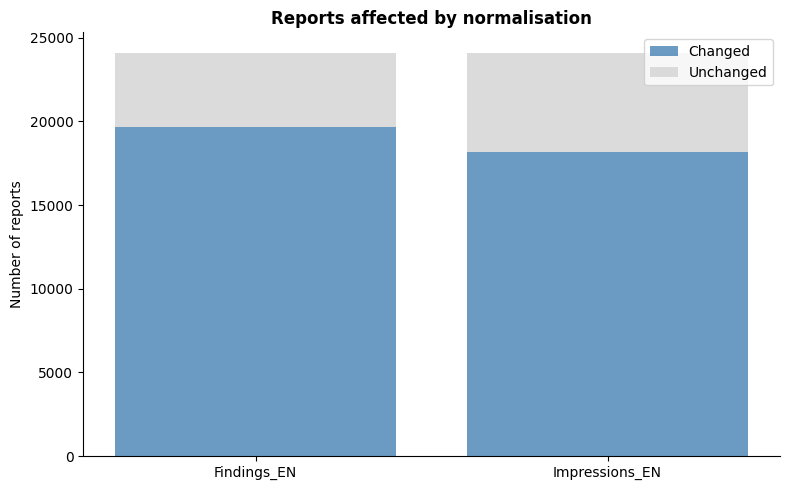

Saved: figures/normalisation_stats.png


In [38]:
# ============================================================
# CELL 10 - Quantify changes
# ============================================================

# how many reports were actually changed?
findings_changed = sum(
    1 for orig, norm in zip(
        df['Findings_EN'].fillna(''),
        df['Findings_EN_norm']
    )
    if orig.lower() != norm
)

impressions_changed = sum(
    1 for orig, norm in zip(
        df['Impressions_EN'].fillna(''),
        df['Impressions_EN_norm']
    )
    if orig.lower() != norm
)

print("=== Normalisation Statistics ===\n")
print(f"Total reports: {len(df)}")
print(f"\nFindings_EN:")
print(f"  Changed: {findings_changed} ({findings_changed/len(df)*100:.1f}%)")
print(f"  Unchanged: {len(df)-findings_changed} ({(len(df)-findings_changed)/len(df)*100:.1f}%)")
print(f"\nImpressions_EN:")
print(f"  Changed: {impressions_changed} ({impressions_changed/len(df)*100:.1f}%)")
print(f"  Unchanged: {len(df)-impressions_changed} ({(len(df)-impressions_changed)/len(df)*100:.1f}%)")

# visualize
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['Findings_EN', 'Impressions_EN']
changed    = [findings_changed, impressions_changed]
unchanged  = [len(df) - c for c in changed]

ax.bar(categories, changed,   label='Changed',   color='steelblue', alpha=0.8)
ax.bar(categories, unchanged, label='Unchanged', color='lightgray',
       alpha=0.8, bottom=changed)

ax.set_title('Reports affected by normalisation',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of reports')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'normalisation_stats.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/normalisation_stats.png")

## 6. Saving Results

We save the normalised dataset and all mappings as JSON for 
reproducibility. The normalised columns are added to the existing 
DataFrame alongside the original text.

In [40]:
# ============================================================
# CELL 11 - Save results
# ============================================================

# save normalised dataset
output_path = '../data/ctrate_train_normalised.csv'
df.to_csv(output_path, index=False)
print(f"Normalised dataset saved: {output_path}")
print(f"Shape: {df.shape}")

# save spelling corrections as JSON
with open('spelling_corrections.json', 'w') as f:
    json.dump(SPELLING_CORRECTIONS, f, indent=2)
print(f"Spelling corrections saved: spelling_corrections.json")

# summary
print(f"\n=== WP3 Summary ===")
print(f"  Reports processed:     {len(df)}")
print(f"  Lexical mappings:      {len(LEXICAL_MAPPINGS)}")
print(f"  Spelling corrections:  {len(SPELLING_CORRECTIONS)}")
print(f"  Findings changed:      {findings_changed} ({findings_changed/len(df)*100:.1f}%)")
print(f"  Impressions changed:   {impressions_changed} ({impressions_changed/len(df)*100:.1f}%)")
print(f"\nWP3 complete!")

Normalised dataset saved: ../data/ctrate_train_normalised.csv
Shape: (24113, 77)
Spelling corrections saved: spelling_corrections.json

=== WP3 Summary ===
  Reports processed:     24113
  Lexical mappings:      19
  Spelling corrections:  21
  Findings changed:      19635 (81.4%)
  Impressions changed:   18177 (75.4%)

WP3 complete!
